In [4]:
from scipy.stats import entropy
from math import log2

In [38]:
def calculate_entropy(probs, tell_if_normalized = True):
    """
    Calculate the Shannon entropy of a list of probabilities.

    :param probs_list: List of probabilities
    :return: Shannon entropy
    """
    if type(probs) == dict:
        probs_values = list(probs.values())
    elif type(probs) == list:
        probs_values = probs
    if sum(probs_values) != 1:
        if tell_if_normalized:
            print(f'Normalized {probs_values} to sum to 1')
        probs_values = [float(i)/sum(probs_values) for i in probs_values]
        
    my_entropy = entropy(list(probs_values), base = 2)
    return my_entropy

In [39]:
def calculate_entropy_loss(merged_probs_dict, probs_dict1, probs_dict2, rel1, rel2):

    entropy1 = calculate_entropy(probs_dict1)
    entropy2 = calculate_entropy(probs_dict2)
    merged_entropy = calculate_entropy(merged_probs_dict, tell_if_normalized = False)
    entropy_loss = (rel1 + rel2)* merged_entropy - rel1*entropy1 - rel2*entropy2

    return entropy_loss

In [40]:
def print_entropies_and_loss(merged_probs_dict, probs_dict1, probs_dict2, rel1, rel2):
    entropy1 = calculate_entropy(probs_dict1)
    entropy2 = calculate_entropy(probs_dict2)
    merged_entropy = calculate_entropy(merged_probs_dict)
    entropy_loss = calculate_entropy_loss(merged_probs_dict, probs_dict1, probs_dict2, rel1, rel2)
    entropy_loss = (rel1 + rel2)* merged_entropy - rel1*entropy1 - rel2*entropy2

    print(f"Entropy 1: {entropy1}")
    print(f"Entropy 2: {entropy2}")
    print(f"Merged Entropy: {merged_entropy}")
    print(f"Entropy Loss: {rel1+rel2} * {merged_entropy:.3f} - {rel1} * {entropy1:.3f} - {rel1} * {entropy2:.3f} = {entropy_loss:.3f}")

### 2 Stripes Model

In [41]:
# Last cells above each other 
p1_probs_dict = { 'c_k1': 1}
p2_probs_dict  = { 'c_k2': 1}
merged_probs_dict = { 'p_k1_k2': 1}
rel1, rel2 = 1, 1
print_entropies_and_loss(merged_probs_dict, p1_probs_dict, p2_probs_dict, rel1, rel2)

Entropy 1: 0.0
Entropy 2: 0.0
Merged Entropy: 0.0
Entropy Loss: 2 * 0.000 - 1 * 0.000 - 1 * 0.000 = 0.000


In [42]:
# Last cells one before the other
p1_probs_dict = { 'c_k1': 1}
p2_probs_dict = { 'c_k1': 0.9, 'c_k2': 0.1}
merged_probs_dict = { 'p': 0.95, 'c_k2': 0.05 }
rel1, rel2 = 1, 1
print_entropies_and_loss(merged_probs_dict, p1_probs_dict, p2_probs_dict, rel1, rel2)

Entropy 1: 0.0
Entropy 2: 0.46899559358928117
Merged Entropy: 0.2863969571159562
Entropy Loss: 2 * 0.286 - 1 * 0.000 - 1 * 0.469 = 0.104


In [43]:
# Last cells one diagonal before the other
p1_probs_dict = { 'c_k1': 1}
p2_probs_dict = { 'c_k1': 0.1, 'c_k2': 0.9}
merged_probs_dict = { 'p': 0.55, 'c_k2': 0.45 }
rel1, rel2 = 1, 1
print_entropies_and_loss(merged_probs_dict, p1_probs_dict, p2_probs_dict, rel1, rel2)

Entropy 1: 0.0
Entropy 2: 0.46899559358928117
Merged Entropy: 0.9927744539878083
Entropy Loss: 2 * 0.993 - 1 * 0.000 - 1 * 0.469 = 1.517


In [44]:
print('Middle column 2 cells')
print_entropies_and_loss([0.5, 0.5], [0.9, 0.1], [0.9, 0.1], 1, 1)

Middle column 2 cells
Entropy 1: 0.46899559358928117
Entropy 2: 0.46899559358928117
Merged Entropy: 1.0
Entropy Loss: 2 * 1.000 - 1 * 0.469 - 1 * 0.469 = 1.062


In [45]:
print('Middle row 2 cells')
print_entropies_and_loss([0.45, 0.45, 0.05, 0.05], [0.9, 0.1], [0.9, 0.1], 1, 1)

Middle row 2 cells
Entropy 1: 0.46899559358928117
Entropy 2: 0.46899559358928117
Merged Entropy: 1.4689955935892813
Entropy Loss: 2 * 1.469 - 1 * 0.469 - 1 * 0.469 = 2.000


In [46]:
print('Middle 2 diagonal cells')
print_entropies_and_loss([0.45, 0.45, 0.05, 0.05], [0.9, 0.1], [0.9, 0.1], 1, 1)

Middle 2 diagonal cells
Entropy 1: 0.46899559358928117
Entropy 2: 0.46899559358928117
Merged Entropy: 1.4689955935892813
Entropy Loss: 2 * 1.469 - 1 * 0.469 - 1 * 0.469 = 2.000


### Transition Probabilities conditioned on leaving the cell

In [47]:
print('Middle column 2 cells')
print_entropies_and_loss([0.5, 0.5], [0.9, 0.1], [0.9, 0.1], 1, 1)

Middle column 2 cells
Entropy 1: 0.46899559358928117
Entropy 2: 0.46899559358928117
Merged Entropy: 1.0
Entropy Loss: 2 * 1.000 - 1 * 0.469 - 1 * 0.469 = 1.062


In [48]:
print('Middle row 2 cells')
print_entropies_and_loss([0.45, 0.05, 0.05], [0.9, 0.1], [0.9, 0.1], 1, 1)

Middle row 2 cells
Normalized [0.45, 0.05, 0.05] to sum to 1
Entropy 1: 0.46899559358928117
Entropy 2: 0.46899559358928117
Merged Entropy: 0.8658566174572238
Entropy Loss: 2 * 0.866 - 1 * 0.469 - 1 * 0.469 = 0.794


In [49]:
print('Middle 2 diagonal cells')
print_entropies_and_loss([0.45, 0.45, 0.05], [0.9, 0.1], [0.9, 0.1], 1, 1)

Middle 2 diagonal cells
Normalized [0.45, 0.45, 0.05] to sum to 1
Entropy 1: 0.46899559358928117
Entropy 2: 0.46899559358928117
Merged Entropy: 1.2448406699719212
Entropy Loss: 2 * 1.245 - 1 * 0.469 - 1 * 0.469 = 1.552


### 2nd Merge

In [ ]:
print('1 before middle column 2 cells')
print_entropies_and_loss([1/3, 1/3, 1/3], [1], [0.5, 0.5], 1, 2)

1 before iddle column 2 cells
Entropy 1: 0.0
Entropy 2: 1.0
Merged Entropy: 1.584962500721156
Entropy Loss: 3 * 1.585 - 1 * 0.000 - 1 * 1.000 = 2.755


In [51]:
print('1 after middle column 2 cells')
print_entropies_and_loss([1/3, 1/3, 1/30, 0.95/3], [0.9, 0.1], [0.5, 0.5], 1, 2)

1 after middle column 2 cells
Normalized [0.3333333333333333, 0.3333333333333333, 0.03333333333333333, 0.31666666666666665] to sum to 1
Entropy 1: 0.46899559358928117
Entropy 2: 1.0
Merged Entropy: 1.7407742793510403
Entropy Loss: 3 * 1.741 - 1 * 0.469 - 1 * 1.000 = 2.753


### 4th Merge cols plus block of 4

In [ ]:
print('Middle col before 4block')
print_entropies_and_loss([2/3,1/3], [1], [0.5, 0.5], 2, 4)

Middle col before block
Entropy 1: 0.0
Entropy 2: 1.0
Merged Entropy: 0.9182958340544894
Entropy Loss: 6 * 0.918 - 2 * 0.000 - 2 * 1.000 = 1.510


In [53]:
print('Middle col before 6block')
print_entropies_and_loss([3/4,1/4], [1], [2/3,1/3], 2, 6)

Middle col before 6block
Entropy 1: 0.0
Entropy 2: 0.9182958340544894
Merged Entropy: 0.8112781244591328
Entropy Loss: 8 * 0.811 - 2 * 0.000 - 2 * 0.918 = 0.980


In [54]:
print('Middle 2 4blocks')
print_entropies_and_loss([3/4,1/4], [0.5, 0.5], [0.5, 0.5], 4, 4)

Middle 2 4blocks
Entropy 1: 1.0
Entropy 2: 1.0
Merged Entropy: 0.8112781244591328
Entropy Loss: 8 * 0.811 - 4 * 1.000 - 4 * 1.000 = -1.510


In [55]:
print('Middle 2 8blocks')
print_entropies_and_loss([7/8,1/8], [3/4,1/4], [3/4,1/4], 8, 8)

Middle 2 8blocks
Entropy 1: 0.8112781244591328
Entropy 2: 0.8112781244591328
Merged Entropy: 0.5435644431995964
Entropy Loss: 16 * 0.544 - 8 * 0.811 - 8 * 0.811 = -4.283


In [56]:
print('Middle 4block with 8block')
print_entropies_and_loss([5/6,1/6], [0.5, 0.5], [3/4,1/4], 4, 8)

Middle 4block with 8block
Entropy 1: 1.0
Entropy 2: 0.8112781244591328
Merged Entropy: 0.6500224216483541
Entropy Loss: 12 * 0.650 - 4 * 1.000 - 4 * 0.811 = -2.690


In [57]:
print('Middle 8block with 16block')
print_entropies_and_loss([11/12,1/12], [7/8,1/8], [3/4,1/4], 16, 8)

Middle 8block with 16block
Entropy 1: 0.5435644431995964
Entropy 2: 0.8112781244591328
Merged Entropy: 0.4138168503036338
Entropy Loss: 24 * 0.414 - 16 * 0.544 - 16 * 0.811 = -5.256


### Merging blocks of columns

In [84]:
def colblock_entropy(size):
    if size == 1:
        return 0
    else:
        return - (1/size * log2(1/size) + ((size-1)/size) * log2((size-1)/size))

entropy_loss_comparison = lambda size : 10/3 * size * ( 4* colblock_entropy(2* size) - colblock_entropy(size) - 3* colblock_entropy(3* size))

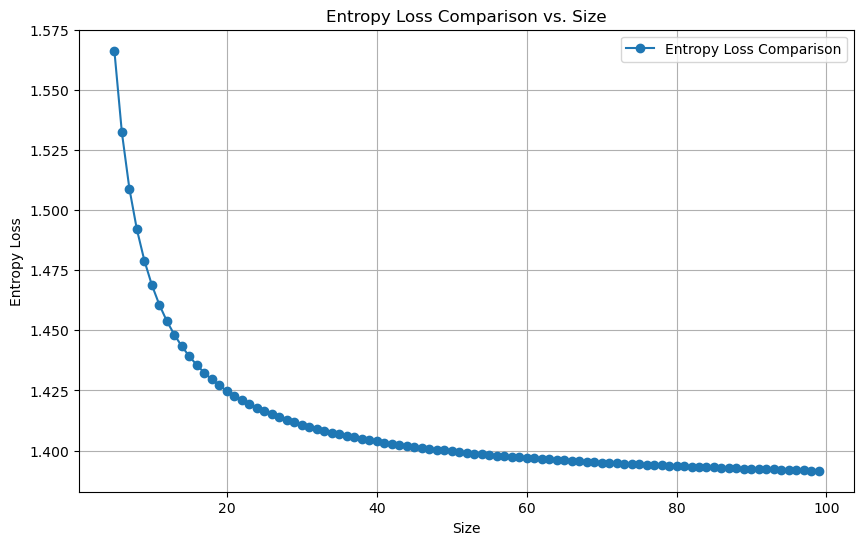

In [90]:
import matplotlib.pyplot as plt

sizes = range(5, 100)  # Define a range of sizes to evaluate
loss_values = [entropy_loss_comparison(size) for size in sizes]

plt.figure(figsize=(10, 6))
plt.plot(sizes, loss_values, marker='o', label='Entropy Loss Comparison')
plt.title('Entropy Loss Comparison vs. Size')
plt.xlabel('Size')
plt.ylabel('Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [86]:
colblock_entropy(2)

1.0

## Loss of Merging - Size Distribution

In [8]:
def calc_loss(distr):
    total = len(distr)
    entr = 0
    for i in range(total):
        entr += distr[i] * log2(distr[i])
    return 1-(-entr/log2(total))

In [ ]:
d1 = [1/2, 1/2]
d2 = [1/4, 1/4, 1/4, 1/4]
d3 = [1/4, 3/4]
d4 = [1/4, 1/4, 1/2]


all = [d1,d2,d3,d4]

In [10]:
for d in all:
    print(calc_loss(d))

0.0
0.0
0.18872187554086717
0.053605369642813816
